*Task 1 Import Libraries*

In [1]:
import pandas as pd
import numpy as np

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler

In [2]:
# Load Dataset
df = pd.read_csv("brca.csv")

In [3]:
# Display First Five Rows
df.head()

,Unnamed: 0,x.radius_mean,x.texture_mean,x.perimeter_mean,x.area_mean,x.smoothness_mean,x.compactness_mean,x.concavity_mean,x.concave_pts_mean,x.symmetry_mean,...,x.texture_worst,x.perimeter_worst,x.area_worst,x.smoothness_worst,x.compactness_worst,x.concavity_worst,x.concave_pts_worst,x.symmetry_worst,x.fractal_dim_worst,y
0,1,13.540,14.36,87.46,566.3,0.09779,0.08129,0.06664,0.047810,0.1885,...,19.26,99.70,711.2,0.14400,0.17730,0.23900,0.12880,0.2977,0.07259,B
1,2,13.080,15.71,85.63,520.0,0.10750,0.12700,0.04568,0.031100,0.1967,...,20.49,96.09,630.5,0.13120,0.27760,0.18900,0.07283,0.3184,0.08183,B
2,3,9.504,12.44,60.34,273.9,0.10240,0.06492,0.02956,0.020760,0.1815,...,15.66,65.13,314.9,0.13240,0.11480,0.08867,0.06227,0.2450,0.07773,B
3,4,13.030,18.42,82.61,523.8,0.08983,0.03766,0.02562,0.029230,0.1467,...,22.81,84.46,545.9,0.09701,0.04619,0.04833,0.05013,0.1987,0.06169,B
4,5,8.196,16.84,51.71,201.9,0.08600,0.05943,0.01588,0.005917,0.1769,...,21.96,57.26,242.2,0.12970,0.13570,0.06880,0.02564,0.3105,0.07409,B


In [4]:
# Dataset Shape
print("Rows and Columns :", df.shape)

Rows and Columns : (569, 32)


The dataset contains 569 observations and 32 columns.

In [5]:
# Column Names
print(df.columns)

Index(['Unnamed: 0', 'x.radius_mean', 'x.texture_mean', 'x.perimeter_mean',
       'x.area_mean', 'x.smoothness_mean', 'x.compactness_mean',
       'x.concavity_mean', 'x.concave_pts_mean', 'x.symmetry_mean',
       'x.fractal_dim_mean', 'x.radius_se', 'x.texture_se', 'x.perimeter_se',
       'x.area_se', 'x.smoothness_se', 'x.compactness_se', 'x.concavity_se',
       'x.concave_pts_se', 'x.symmetry_se', 'x.fractal_dim_se',
       'x.radius_worst', 'x.texture_worst', 'x.perimeter_worst',
       'x.area_worst', 'x.smoothness_worst', 'x.compactness_worst',
       'x.concavity_worst', 'x.concave_pts_worst', 'x.symmetry_worst',
       'x.fractal_dim_worst', 'y'],
      dtype='object')


list all the column names

In [6]:
# Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           569 non-null    int64  
 1   x.radius_mean        569 non-null    float64
 2   x.texture_mean       569 non-null    float64
 3   x.perimeter_mean     569 non-null    float64
 4   x.area_mean          569 non-null    float64
 5   x.smoothness_mean    569 non-null    float64
 6   x.compactness_mean   569 non-null    float64
 7   x.concavity_mean     569 non-null    float64
 8   x.concave_pts_mean   569 non-null    float64
 9   x.symmetry_mean      569 non-null    float64
 10  x.fractal_dim_mean   569 non-null    float64
 11  x.radius_se          569 non-null    float64
 12  x.texture_se         569 non-null    float64
 13  x.perimeter_se       569 non-null    float64
 14  x.area_se            569 non-null    float64
 15  x.smoothness_se      569 non-null    flo

The dataset consists primarily of numerical features describing cell characteristics. The target variable (y) is categorical with two classes: Benign (B) and Malignant (M).

In [7]:
# Statistical Summary
df.describe()

,Unnamed: 0,x.radius_mean,x.texture_mean,x.perimeter_mean,x.area_mean,x.smoothness_mean,x.compactness_mean,x.concavity_mean,x.concave_pts_mean,x.symmetry_mean,...,x.radius_worst,x.texture_worst,x.perimeter_worst,x.area_worst,x.smoothness_worst,x.compactness_worst,x.concavity_worst,x.concave_pts_worst,x.symmetry_worst,x.fractal_dim_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,285.000000,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,164.400426,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,1.000000,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,143.000000,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,285.000000,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,427.000000,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,569.000000,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


The statistical summary provides measures such as mean, standard deviation, minimum, maximum, and quartiles, helping us understand the distribution and variability of each numerical feature.

In [8]:
# Missing Values
print(df.isnull().sum())

Unnamed: 0             0
x.radius_mean          0
x.texture_mean         0
x.perimeter_mean       0
x.area_mean            0
x.smoothness_mean      0
x.compactness_mean     0
x.concavity_mean       0
x.concave_pts_mean     0
x.symmetry_mean        0
x.fractal_dim_mean     0
x.radius_se            0
x.texture_se           0
x.perimeter_se         0
x.area_se              0
x.smoothness_se        0
x.compactness_se       0
x.concavity_se         0
x.concave_pts_se       0
x.symmetry_se          0
x.fractal_dim_se       0
x.radius_worst         0
x.texture_worst        0
x.perimeter_worst      0
x.area_worst           0
x.smoothness_worst     0
x.compactness_worst    0
x.concavity_worst      0
x.concave_pts_worst    0
x.symmetry_worst       0
x.fractal_dim_worst    0
y                      0
dtype: int64


There are no missing values in the dataset. Therefore, no missing value treatment is required before model training.

In [9]:
# Duplicate Records
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


The dataset does not contain duplicate records, indicating that every observation is unique.

In [10]:
# Remove Index Column
df = df.drop("Unnamed: 0", axis=1)

In [11]:
# verify
df.head()

,x.radius_mean,x.texture_mean,x.perimeter_mean,x.area_mean,x.smoothness_mean,x.compactness_mean,x.concavity_mean,x.concave_pts_mean,x.symmetry_mean,x.fractal_dim_mean,...,x.texture_worst,x.perimeter_worst,x.area_worst,x.smoothness_worst,x.compactness_worst,x.concavity_worst,x.concave_pts_worst,x.symmetry_worst,x.fractal_dim_worst,y
0,13.540,14.36,87.46,566.3,0.09779,0.08129,0.06664,0.047810,0.1885,0.05766,...,19.26,99.70,711.2,0.14400,0.17730,0.23900,0.12880,0.2977,0.07259,B
1,13.080,15.71,85.63,520.0,0.10750,0.12700,0.04568,0.031100,0.1967,0.06811,...,20.49,96.09,630.5,0.13120,0.27760,0.18900,0.07283,0.3184,0.08183,B
2,9.504,12.44,60.34,273.9,0.10240,0.06492,0.02956,0.020760,0.1815,0.06905,...,15.66,65.13,314.9,0.13240,0.11480,0.08867,0.06227,0.2450,0.07773,B
3,13.030,18.42,82.61,523.8,0.08983,0.03766,0.02562,0.029230,0.1467,0.05863,...,22.81,84.46,545.9,0.09701,0.04619,0.04833,0.05013,0.1987,0.06169,B
4,8.196,16.84,51.71,201.9,0.08600,0.05943,0.01588,0.005917,0.1769,0.06503,...,21.96,57.26,242.2,0.12970,0.13570,0.06880,0.02564,0.3105,0.07409,B


now 31 columns only.

In [12]:
# Convert Target Variable
df['y'] = df['y'].map({'M':0,'B':1})

0 → Malignant

1 → Benign

In [13]:
# checking
df['y'].value_counts()

y
1    357
0    212
Name: count, dtype: int64

The categorical target labels have been converted into numerical values, where 0 represents Malignant and 1 represents Benign, making the data suitable for machine learning algorithms.

In [14]:
# Separate Features and Target
X = df.drop('y', axis=1)

y = df['y']

In [ ]:
#  Feature Scaling
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

Why is Feature Scaling Required?

KNN calculates distances between data points. Features with larger numerical values can dominate the distance calculation, leading to biased predictions. StandardScaler standardizes all features to have zero mean and unit variance, ensuring that every feature contributes equally to the distance computation.

*Task 2: Train-Test Split Analysis*

In [16]:
# Import Required Libraries
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import math

In [17]:
# Train-Test Split (80:20)
X_train80, X_test80, y_train80, y_test80 = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42
)

k80 = int(math.sqrt(len(X_train80)))

knn80 = KNeighborsClassifier(n_neighbors=k80)
knn80.fit(X_train80, y_train80)

y_pred80 = knn80.predict(X_test80)

accuracy80 = accuracy_score(y_test80, y_pred80)

print("Training Samples :", len(X_train80))
print("Testing Samples :", len(X_test80))
print("Heuristic K :", k80)
print("Accuracy :", accuracy80)

Training Samples : 455
Testing Samples : 114
Heuristic K : 21
Accuracy : 0.9298245614035088


The 80:20 train-test split uses 455 samples for training and 114 samples for testing. Using the heuristic K = 21, the KNN classifier achieved an accuracy of 92.98%, indicating good classification performance while maintaining a balanced split for training and evaluation.

In [18]:
# Train-Test Split (70:30)
X_train70, X_test70, y_train70, y_test70 = train_test_split(
    X_scaled,
    y,
    test_size=0.30,
    random_state=42
)

k70 = int(math.sqrt(len(X_train70)))

knn70 = KNeighborsClassifier(n_neighbors=k70)
knn70.fit(X_train70, y_train70)

y_pred70 = knn70.predict(X_test70)

accuracy70 = accuracy_score(y_test70, y_pred70)

print("Training Samples :", len(X_train70))
print("Testing Samples :", len(X_test70))
print("Heuristic K :", k70)
print("Accuracy :", accuracy70)

Training Samples : 398
Testing Samples : 171
Heuristic K : 19
Accuracy : 0.935672514619883


The 70:30 train-test split uses 398 samples for training and 171 samples for testing. Using the heuristic K = 19, the KNN classifier achieved an accuracy of 93.57%, showing slightly better performance while evaluating the model on a larger test set.

In [19]:
# Train-Test Split (90:10)
X_train90, X_test90, y_train90, y_test90 = train_test_split(
    X_scaled,
    y,
    test_size=0.10,
    random_state=42
)

k90 = int(math.sqrt(len(X_train90)))

knn90 = KNeighborsClassifier(n_neighbors=k90)
knn90.fit(X_train90, y_train90)

y_pred90 = knn90.predict(X_test90)

accuracy90 = accuracy_score(y_test90, y_pred90)

print("Training Samples :", len(X_train90))
print("Testing Samples :", len(X_test90))
print("Heuristic K :", k90)
print("Accuracy :", accuracy90)

Training Samples : 512
Testing Samples : 57
Heuristic K : 22
Accuracy : 0.8947368421052632


The model achieved an accuracy of 89.47% using 512 training samples and 57 testing samples. Although more training data was available, the smaller test set made the evaluation more sensitive to misclassifications.

Analyze how dataset splitting affects model stability and generalization

The train-test split influences both model learning and evaluation. A larger training set can improve learning, while a larger testing set provides a more reliable estimate of model performance. In this experiment, the 70:30 split produced the highest accuracy (93.57%), whereas the 90:10 split produced the lowest accuracy (89.47%) due to the smaller test set. Overall, the 80:20 and 70:30 splits provided more stable and reliable performance than the 90:10 split.

*Task 3: KNN Model with Heuristic K Selection*

In [20]:
# Heuristic Method for K Selection
import math

heuristic_k = int(math.sqrt(len(X_train80)))

print("Training Samples :", len(X_train80))
print("Heuristic K :", heuristic_k)

Training Samples : 455
Heuristic K : 21


Using the heuristic rule K=√n the initial value of K is 21, which serves as the baseline for training the KNN classifier.

In [21]:
# Model Training
knn = KNeighborsClassifier(n_neighbors=heuristic_k)

knn.fit(X_train80, y_train80)

y_pred = knn.predict(X_test80)

accuracy = accuracy_score(y_test80, y_pred)

print("Heuristic K :", heuristic_k)
print("Accuracy :", accuracy)

Heuristic K : 21
Accuracy : 0.9298245614035088


The KNN classifier trained with the heuristic value K = 21 achieved an accuracy of 92.98%, indicating good classification performance.

In [22]:
# Experiment with Nearby Values (K ± 5)
k_values = list(range(16,27))

accuracy_list = []

for k in k_values:

    knn = KNeighborsClassifier(n_neighbors=k)

    knn.fit(X_train80,y_train80)

    y_pred = knn.predict(X_test80)

    acc = accuracy_score(y_test80,y_pred)

    accuracy_list.append(acc)

    print(f"K = {k}, Accuracy = {acc:.4f}")

K = 16, Accuracy = 0.9474
K = 17, Accuracy = 0.9474
K = 18, Accuracy = 0.9561
K = 19, Accuracy = 0.9298
K = 20, Accuracy = 0.9474
K = 21, Accuracy = 0.9298
K = 22, Accuracy = 0.9298
K = 23, Accuracy = 0.9298
K = 24, Accuracy = 0.9298
K = 25, Accuracy = 0.9298
K = 26, Accuracy = 0.9386


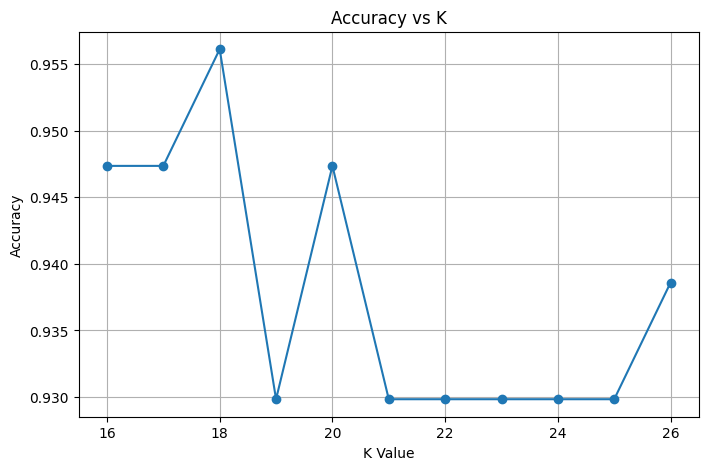

In [23]:
# Plot Accuracy vs K
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(k_values,
         accuracy_list,
         marker='o')

plt.xlabel("K Value")

plt.ylabel("Accuracy")

plt.title("Accuracy vs K")

plt.grid(True)

plt.show()

The graph illustrates the variation in classification accuracy for different values of K. The accuracy increases from K = 16 and reaches its maximum value of 95.61% at K = 18. Beyond K = 18, the accuracy generally decreases and remains relatively stable around 92.98%, indicating that K = 18 is the optimal value for this dataset.

(Part A): Distance Metrics

1. Euclidean Distance
Definition

Euclidean distance measures the straight-line distance between two data points.

$$
d = \sqrt{\sum_{i=1}^{n}(x_i - y_i)^2}
$$
When is it suitable?

Euclidean distance is suitable for continuous numerical data when all features are properly scaled and the shortest straight-line distance is meaningful.
​

2. Manhattan Distance
Definition

Manhattan distance measures the sum of the absolute differences between corresponding feature values.

$$
d = \sum_{i=1}^{n} |x_i - y_i|
$$

When is it suitable?

Manhattan distance is suitable when the data contains high-dimensional features or outliers, as it is less affected by large differences than Euclidean distance.

(Part B): Decision Boundary Mapping

In [24]:
# Step 1: Import Libraries
from sklearn.decomposition import PCA
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt
import numpy as np

In [25]:
# Step 2: Reduce the Data to 2 Dimensions
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

In [26]:
# Step 3: Train-Test Split on PCA Data
X_train, X_test, y_train, y_test = train_test_split(
    X_pca,
    y,
    test_size=0.20,
    random_state=42
)

In [28]:
# Step 4: Function to Plot Decision Boundary
def plot_decision_boundary(k):

    knn = KNeighborsClassifier(n_neighbors=k)

    knn.fit(X_train, y_train)

    x_min, x_max = X_train[:,0].min()-1, X_train[:,0].max()+1
    y_min, y_max = X_train[:,1].min()-1, X_train[:,1].max()+1

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, 0.02),
        np.arange(y_min, y_max, 0.02)
    )

    Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(6,5))

    plt.contourf(xx, yy, Z,
                 alpha=0.3,
                 cmap=ListedColormap(('red','green')))

    plt.scatter(
        X_train[:,0],
        X_train[:,1],
        c=y_train,
        edgecolor='k',
        cmap=ListedColormap(('red','green'))
    )

    plt.title(f"KNN Decision Boundary (K = {k})")

    plt.xlabel("Principal Component 1")

    plt.ylabel("Principal Component 2")

    plt.show()

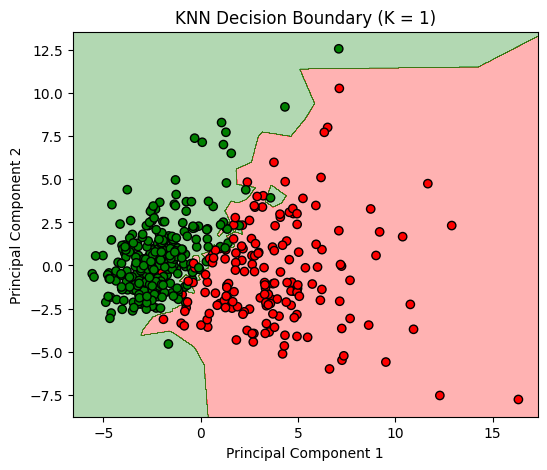

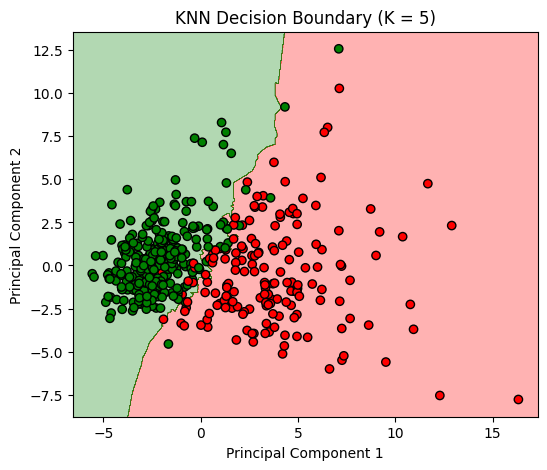

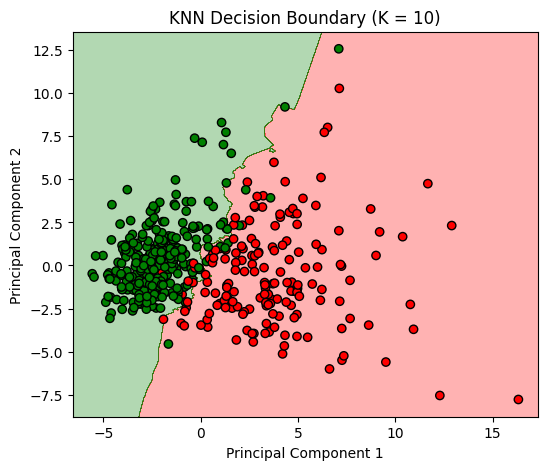

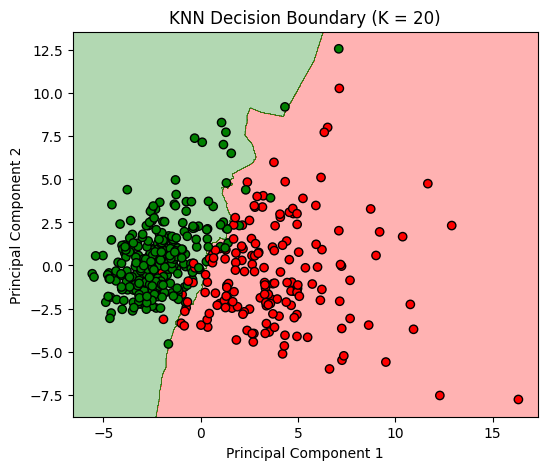

In [29]:
# Step 5: Plot for Different K Values
plot_decision_boundary(1)

plot_decision_boundary(5)

plot_decision_boundary(10)

plot_decision_boundary(20)

K = 1

The decision boundary is highly irregular and closely follows the training data, making the model prone to overfitting.

K = 5

The decision boundary is smoother than K = 1, reducing overfitting while maintaining good classification performance.

k=10
The decision boundary is smoother than K = 5, indicating better generalization with reduced sensitivity to individual data points.

k=20
The decision boundary is much smoother, indicating higher bias and a slight tendency toward underfitting, while still separating the classes reasonably well.

*Task 4: Cross Validation*

In [30]:
# Step 1: Import Libraries
from sklearn.model_selection import cross_val_score

In [31]:
# Step 2: Compute Cross-Validation Accuracy for Different K Values
k_values = list(range(16, 27))

cv_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)

    scores = cross_val_score(knn, X_scaled, y, cv=5, scoring='accuracy')

    cv_scores.append(scores.mean())

    print(f"K = {k}, Mean Accuracy = {scores.mean():.4f}")

K = 16, Mean Accuracy = 0.9666
K = 17, Mean Accuracy = 0.9596
K = 18, Mean Accuracy = 0.9596
K = 19, Mean Accuracy = 0.9543
K = 20, Mean Accuracy = 0.9543
K = 21, Mean Accuracy = 0.9526
K = 22, Mean Accuracy = 0.9543
K = 23, Mean Accuracy = 0.9543
K = 24, Mean Accuracy = 0.9561
K = 25, Mean Accuracy = 0.9543
K = 26, Mean Accuracy = 0.9526


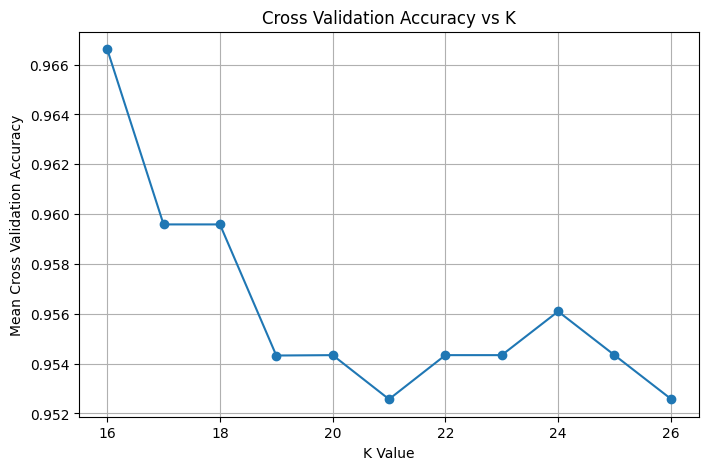

In [32]:
# Step 3: Plot Mean Accuracy vs K
plt.figure(figsize=(8,5))

plt.plot(k_values, cv_scores, marker='o')

plt.xlabel("K Value")

plt.ylabel("Mean Cross Validation Accuracy")

plt.title("Cross Validation Accuracy vs K")

plt.grid(True)

plt.show()

The graph shows that the highest mean cross-validation accuracy (96.66%) is achieved at K = 16. As K increases, the accuracy gradually decreases with minor fluctuations, indicating that K = 16 provides the best performance.

In [33]:
# Step 4: Find the Best K
best_k_cv = k_values[np.argmax(cv_scores)]
best_accuracy_cv = max(cv_scores)

print("Best K:", best_k_cv)
print("Best Mean Accuracy:", round(best_accuracy_cv,4))

Best K: 16
Best Mean Accuracy: 0.9666


The 5-fold cross-validation results show that K = 16 achieved the highest mean accuracy of 96.66%. Therefore, K = 16 is selected as the optimal K value based on cross-validation.

3.Comparison with Train-Test Split

Method	        Best K	Accuracy
Train-Test Split	18	95.61%
Cross Validation	16	96.66%

The train-test split identified K = 18 as the best value, whereas 5-fold cross-validation selected K = 16 with a higher mean accuracy. Cross-validation is more reliable because it evaluates the model across multiple folds, reducing the effect of a single train-test split.

4.Final K Selection
Heuristic K: 21
Best K (Train-Test): 18
Best K (Cross-Validation): 16

Although the heuristic rule suggested K = 21, experimental evaluation identified K = 18 as the best value using the train-test split, while K = 16 achieved the highest mean accuracy through cross-validation. Hence, K = 16 is selected as the final K value for model evaluation.


*Task 5: Classification Evaluation*

In [34]:
# Step 1: Import Required Libraries
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)

In [42]:
# Step 2: Train the Final Model
final_knn = KNeighborsClassifier(n_neighbors=16)

final_knn.fit(X_train80, y_train80)

y_pred = final_knn.predict(X_test80)

In [35]:
# Step 3: Accuracy
accuracy = accuracy_score(y_test80, y_pred)

print("Accuracy :", round(accuracy,4))

Accuracy : 0.9386


The KNN classifier achieved an accuracy of 93.86%, indicating that it correctly classified 93.86% of the test samples.

In [36]:
# Step 4: Precision
precision = precision_score(y_test80, y_pred)

print("Precision :", round(precision,4))

Precision : 0.9103


The model achieved a precision of 91.03%, indicating that 91.03% of the samples predicted as benign were actually benign.By default it uses pos_label=1.1 is benign(class=1).

In [37]:
# Step 5: Recall
recall = recall_score(y_test80, y_pred)

print("Recall :", round(recall,4))

Recall : 1.0


Recall : 1.0

The model achieved a recall of 100%, indicating that all actual benign samples in the test set were correctly identified by the classifier.

In [38]:
# Step 6: F1 Score
f1 = f1_score(y_test80, y_pred)

print("F1 Score :", round(f1,4))

F1 Score : 0.953


The model achieved an F1 Score of 95.30%, indicating a good balance between precision and recall for the positive class (Benign).

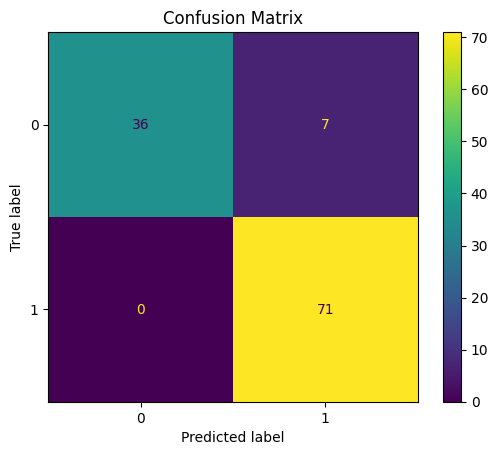

In [39]:
# Step 7: Confusion Matrix
cm = confusion_matrix(y_test80, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()

plt.title("Confusion Matrix")

plt.show()

True Positives (TP) = 71
True Negatives (TN) = 36
False Positives (FP) = 7
False Negatives (FN) = 0
Recall = TP / (TP + FN) = 71 / (71 + 0) = 1.0
The confusion matrix shows that the model correctly classified 36 malignant and 71 benign cases, with 7 malignant cases incorrectly classified as benign and no benign cases misclassified as malignant.

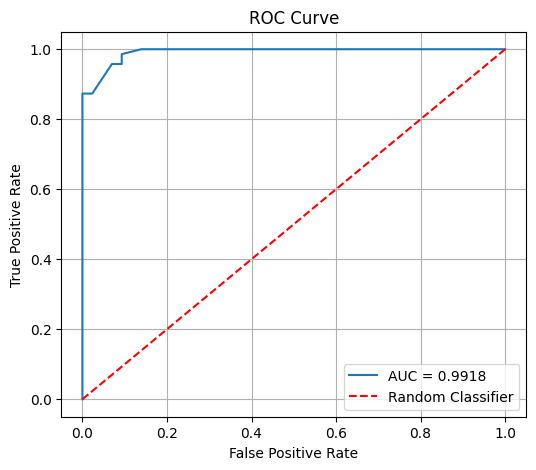

AUC Score : 0.9918


In [44]:
from sklearn.metrics import roc_curve, roc_auc_score

# Predict probabilities for the positive class (Benign = 1)
y_prob = final_knn.predict_proba(X_test80)[:, 1]

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test80, y_prob)

# Compute AUC score
auc_score = roc_auc_score(y_test80, y_prob)

# Plot ROC Curve
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.4f}")
plt.plot([0, 1], [0, 1], 'r--', label='Random Classifier')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)

plt.show()

# Print AUC Score
print("AUC Score :", round(auc_score, 4))

he ROC curve lies close to the top-left corner, indicating that the KNN classifier effectively distinguishes between benign and malignant cases with a high true positive rate and a low false positive rate.

AUC Score Interpretation

The AUC score of 0.9918 indicates excellent classification performance, showing that the model has a very high ability to distinguish between benign and malignant cases.

*Task 6: Comparative Study with Regression (Lab 3 Integration)*

6.1 Compare Regression Evaluation Metrics with Classification Metrics

 Regression Metrics  Classification Metrics 

 MAE                 Confusion Matrix       
 MSE                 Precision              
 RMSE                F1 Score               
 R² Score            Accuracy               

6.2 Error-based Evaluation (Regression) vs Decision-based Evaluation (Classification)

 <h3>Error-based Evaluation (Regression) vs Decision-based Evaluation (Classification)</h3>

<table border="1">
<tr>
<th>Error-based Evaluation (Regression)</th>
<th>Decision-based Evaluation (Classification)</th>
</tr>

<tr>
<td>Used for continuous numerical prediction.</td>
<td>Used for predicting class labels.</td>
</tr>

<tr>
<td>Measures the difference between actual and predicted values.</td>
<td>Measures whether the predicted class is correct or incorrect.</td>
</tr>

<tr>
<td>Uses MAE, MSE, RMSE and R² Score.</td>
<td>Uses Accuracy, Precision, Recall, F1 Score and ROC-AUC.</td>
</tr>

</table>


6.3 R² Score vs Accuracy

<h3>R² Score vs Accuracy</h3>

<table border="1">
<tr>
<th>R² Score</th>
<th>Accuracy</th>
</tr>

<tr>
<td>Measures how well the regression model explains the variation in the data.</td>
<td>Measures the percentage of correctly classified instances.</td>
</tr>

<tr>
<td>Used in regression problems.</td>
<td>Used in classification problems.</td>
</tr>

</table>

6.4 RMSE vs F1 Score

<h3>RMSE vs F1 Score</h3>

<table border="1">
<tr>
<th>RMSE</th>
<th>F1 Score</th>
</tr>

<tr>
<td>Measures the average magnitude of prediction error.</td>
<td>Measures the balance between precision and recall.</td>
</tr>

<tr>
<td>Lower RMSE indicates better performance.</td>
<td>Higher F1 Score indicates better classification performance.</td>
</tr>

</table>

6.5 MAE vs Confusion Matrix

<h3>MAE vs Confusion Matrix</h3>

<table border="1">
<tr>
<th>MAE</th>
<th>Confusion Matrix</th>
</tr>

<tr>
<td>Measures the average absolute prediction error.</td>
<td>Shows the number of correct and incorrect classifications.</td>
</tr>

<tr>
<td>Used for regression.</td>
<td>Used for classification.</td>
</tr>

</table>

6.6 Continuous Prediction Tasks vs Classification Tasks

<h3>Continuous Prediction Tasks vs Classification Tasks</h3>

<table border="1">
<tr>
<th>Continuous Prediction Tasks</th>
<th>Classification Tasks</th>
</tr>

<tr>
<td>Predict continuous numerical values.</td>
<td>Predict categorical class labels.</td>
</tr>

<tr>
<td>Example: House price prediction.</td>
<td>Example: Breast cancer diagnosis.</td>
</tr>

<tr>
<td>Evaluated using MAE, MSE, RMSE and R² Score.</td>
<td>Evaluated using Accuracy, Precision, Recall, F1 Score and ROC-AUC.</td>
</tr>

</table>

How regression metrics measure prediction error magnitude?

Regression metrics measure prediction error magnitude by comparing predicted values and actual values.Lower values in - MAE, MSE, and RMSE indicate better prediction accuracy.  Higher R² Score indicates a better fit of the regression model.


How classification metrics measure decision correctness?

Classification evaluation metrics (Accuracy, Precision,Recall, F1 Score,ROC-AUC) measure how correctly the model classifies data into different categories. These metrics evaluate the correctness of predictions rather than the magnitude of errors.

Why is accuracy insufficient in medical diagnosis?

accuracy alone is not sufficient because a model can achieve high accuracy while still failing to detect patients with the disease. Misclassifying a patient with cancer as healthy can have serious consequences.

Why recall and ROC-AUC are more relevant in healthcare?

it measures the model's ability to correctly identify actual positive cases.so chance of missing diseased person can be reduced.Evaluates the model's ability to distinguish between different classes across various classification

Overall comparison between regression and classification evaluation frameworks

Regression focuses on minimizing prediction errors for continuous values.
classification focuses on correctly assigning class labels using decision-based performance metrics.evaluate the correctness of class predictions.

*Task 7: Analytical Questions*

1. Why is KNN called a lazy learning algorithm?

KNN is called a lazy learning algorithm because it does not build a model during training and stores the training data until a prediction is required.

2. Why is feature scaling required in KNN?

Feature scaling is required because KNN uses distance calculations, and scaling ensures that all features contribute equally to the distance measurement.

3. Explain heuristic K selection using √n rule.

The heuristic method selects the initial value of K using K=√n
, where n is the number of training samples, providing a reasonable starting point for model tuning.

4. Why is cross-validation more reliable than a single train-test split?

Cross-validation evaluates the model on multiple data splits, providing a more reliable estimate of performance than a single train-test split.

5. How does K affect the bias-variance trade-off?

A small K value may lead to overfitting with high variance, while a large K value may lead to underfitting with high bias.

6. Why is recall more important than accuracy in cancer prediction?

Recall is more important because it minimizes false negatives, reducing the chance of missing patients who actually have cancer.

7. What is the limitation of very large K values?

Very large K values may oversimplify the decision boundary, causing underfitting and reducing classification accuracy.

Conclusion

The KNN classifier was successfully implemented on the Breast Cancer Wisconsin dataset. The heuristic method suggested K = 21, while experimentation identified K = 18 as the best value using the train-test split. Further evaluation using 5-fold cross-validation selected K = 16 with the highest mean accuracy (96.66%). The final model achieved an accuracy of 93.86%, precision of 91.03%, recall of 100%, F1-score of 95.30%, and an AUC score of 0.9918, indicating excellent classification performance. This lab also highlighted the differences between regression and classification evaluation metrics and demonstrated the importance of cross-validation and appropriate metric selection in medical diagnosis.